In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import random
import matplotlib.pyplot as plt
from skimage.util import random_noise
from tensorflow.keras.layers import Layer, Conv2D, Add, ReLU, Concatenate, GlobalAveragePooling2D, Multiply, Input, Lambda,  MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from keras.models import load_model
from tensorflow.keras.saving import register_keras_serializable


In [2]:

def preprocess(sample, img_size):
    """Preprocessa le immagini: ridimensionamento e normalizzazione."""
    image = tf.image.resize(sample['image'], img_size) / 255.0  # Normalizza in [0,1]
    label = sample['label']  # Estrai l'etichetta
    return image, label

def load_dataset(split='train', img_size=(256,256), batch_size=16):
    """
    Carica il dataset Oxford-IIIT Pet da tfds e applica il preprocessamento.
    Ritorna un dataset in batch.
    """
    ds_split = 'train[:80%]'
    if(split == 'validation'):
      ds_split = 'train[80%:]'
    elif(split != 'train' or split != 'validation'):
      ds_split = 'test'

    print(ds_split)
    dataset = tfds.load('oxford_iiit_pet', split=ds_split, as_supervised=False)  # as_supervised=False per mantenere dict
    dataset = dataset.map(lambda sample: preprocess(sample, img_size))  # Preprocessing
    dataset = dataset.shuffle(1024).batch(batch_size).prefetch(tf.data.AUTOTUNE)  # Ottimizza il caricamento
    return dataset



In [18]:
# Parametri
img_size = (112, 112)
batch_size = 32
noise_factor = 0.3
epochs = 50

# Caricamento dataset
train_ds = load_dataset( split='train',      img_size=img_size, batch_size=batch_size)
valid_ds = load_dataset( split='validation', img_size=img_size, batch_size=batch_size)
test_ds  = load_dataset( split='test',       img_size=img_size, batch_size=batch_size)

In [19]:
def add_noise(x, noise_factor=0.1):
    noise = tf.random.normal(shape=tf.shape(x), mean=0.0, stddev=1.0)
    x_noisy = x + noise_factor * noise
    return x_noisy

In [20]:
train_ds_noisy = train_ds.map(lambda x, label: (add_noise(x, noise_factor), x))
valid_ds_noisy = train_ds.map(lambda x, label: (add_noise(x, noise_factor), x))

In [21]:
def plot_side_by_side(x_noisy, x_original, n=10):
    """
    Visualizza n coppie di immagini affiancando l'immagine rumorosa e quella originale per immagini a colori.
    """
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # Immagine rumorosa
        ax = plt.subplot(2, n, i+1)
        plt.imshow(x_noisy[i])
        plt.title("Rumorosa")
        plt.axis('off')

        # Immagine originale
        ax = plt.subplot(2, n, i+1+n)
        plt.imshow(x_original[i])
        plt.title("Originale")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

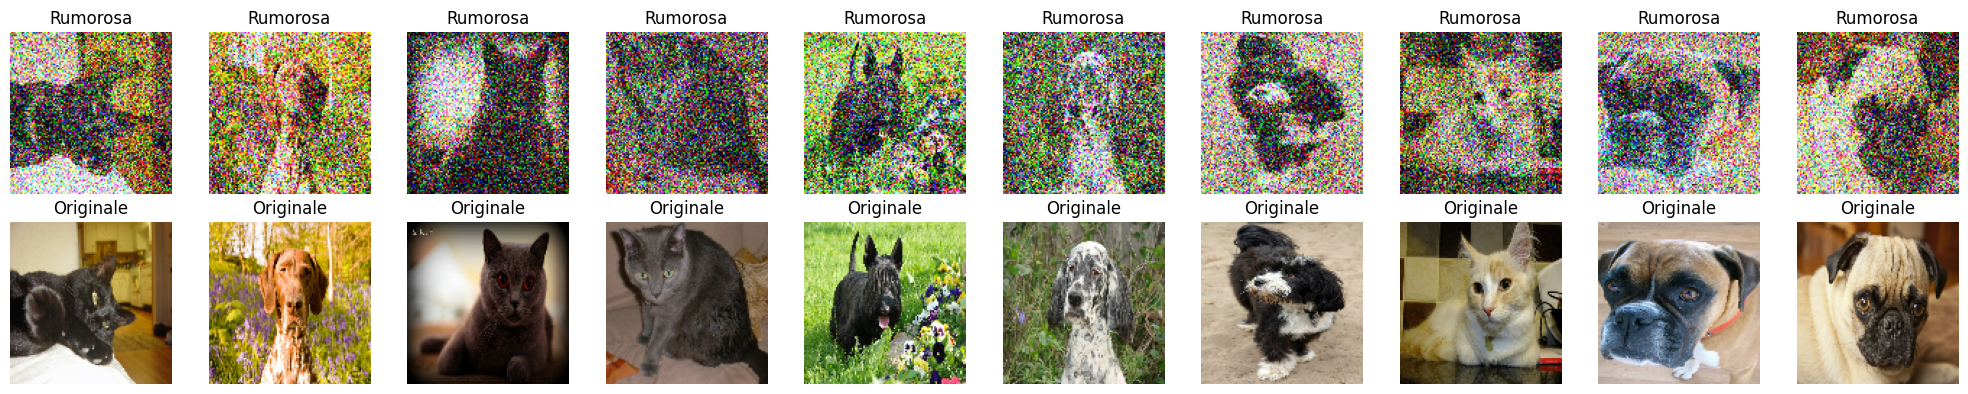

In [22]:
# Prendi un batch dal dataset (ad esempio, il primo batch)
batch = next(iter(train_ds_noisy))
x_noisy_batch, x_original_batch = batch

# Converti i tensori in array NumPy
x_noisy_np = x_noisy_batch.numpy()
x_original_np = x_original_batch.numpy()

# Usa la funzione plot_side_by_side per visualizzare n immagini
plot_side_by_side(x_noisy_np, x_original_np, n=10)


Creazione modello

In [23]:
def plot_denoising_results(x_test_noisy, decoded_imgs, x_test, n=10):
    """
    Visualizza n immagini rumorose, le rispettive immagini denoised e quelle originali.
    """
    plt.figure(figsize=(20, 4))
    n = 10
    for i in range(n):
        # Immagine rumorosa
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(x_test_noisy[i])
        plt.title("Rumorosa")
        plt.axis('off')
        # Immagine denoised
        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(decoded_imgs[i])
        plt.title("Denoised")
        plt.axis('off')
        # Immagine originale
        ax = plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(x_test[i])
        plt.title("Originale")
        plt.axis('off')
    plt.tight_layout()
    plt.show()


In [24]:
def psnr(original, denoised):
  mse = np.mean((original - denoised) ** 2)
  if mse == 0:
    return float('inf') # immagini identiche
  max_pixel = 1.0 # valore massimo per immagini normalizzate in [0, 1]
  return 10 * np.log10((max_pixel ** 2) / mse)

In [25]:
def build_autoencoder(input_shape):
    """
    Costruisce un autoencoder convoluzionale per immagini a colori.
    Parametri:
      input_shape: forma dell'immagine in input (es. (32,32,3))
    Ritorna:
      autoencoder: modello compilato
    """
    input_img = Input(shape=input_shape)

    # Encoder
    x = Conv2D(64, (3,3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2,2), padding='same')(x)
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2,2), padding='same')(x)

    # Decoder
    x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
    x = UpSampling2D((2,2))(x)
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = UpSampling2D((2,2))(x)
    decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

    autoencoder = Model(input_img, decoded)
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    return autoencoder

def train_autoencoder(autoencoder, x_train_noisy, x_train, x_test_noisy, x_test, epochs=50, batch_size=128):
    """
    Addestra l'autoencoder utilizzando le immagini rumorose come input e quelle originali come target.
    """
    history = autoencoder.fit(x_train_noisy, x_train,
                              epochs=epochs,
                              batch_size=batch_size,
                              shuffle=True,
                              validation_data=(x_test_noisy, x_test))
    return history

In [26]:
autoencoder = build_autoencoder(input_shape=(img_size[0], img_size[1], 3))
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 112, 112, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 112, 112, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,307 (446.51 KB)

 Trainable params: 114,307 (446.51 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history = autoencoder.fit(train_ds_noisy,
                validation_data=valid_ds_noisy,
                batch_size=batch_size,
                epochs=50)

Epoch 1/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 24s 372ms/step - accuracy: 0.7055 - loss: 0.5410 - val_accuracy: 0.7091 - val_loss: 0.5419
Epoch 2/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 20s 313ms/step - accuracy: 0.7087 - loss: 0.5403 - val_accuracy: 0.7271 - val_loss: 0.5391
Epoch 3/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 21s 325ms/step - accuracy: 0.7124 - loss: 0.5371 - val_accuracy: 0.7274 - val_loss: 0.5378
Epoch 4/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 22s 353ms/step - accuracy: 0.7164 - loss: 0.5373 - val_accuracy: 0.7168 - val_loss: 0.5375
Epoch 5/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 20s 320ms/step - accuracy: 0.7142 - loss: 0.5362 - val_accuracy: 0.7302 - val_loss: 0.5380
Epoch 6/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 42s 329ms/step - accuracy: 0.7192 - loss: 0.5379 - val_accuracy: 0.7182 - val_loss: 0.5370
Epoch 7/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 21s 336ms/step - accuracy: 0.7168 - loss: 0.5382 - val_accuracy: 0.7230 - val_loss: 0.5366
Epoch 8/50
58/58 ━━━━━━━━━━━━━━━━━━━━ 20s 309ms/step - accuracy: 0.7227 - loss: 0.5362 - val_accu

In [43]:
test_ds_noisy = test_ds.map(lambda x, label: (add_noise(x, noise_factor), x))

In [44]:
decoded_imgs = autoencoder.predict(test_ds_noisy)

58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 153ms/step


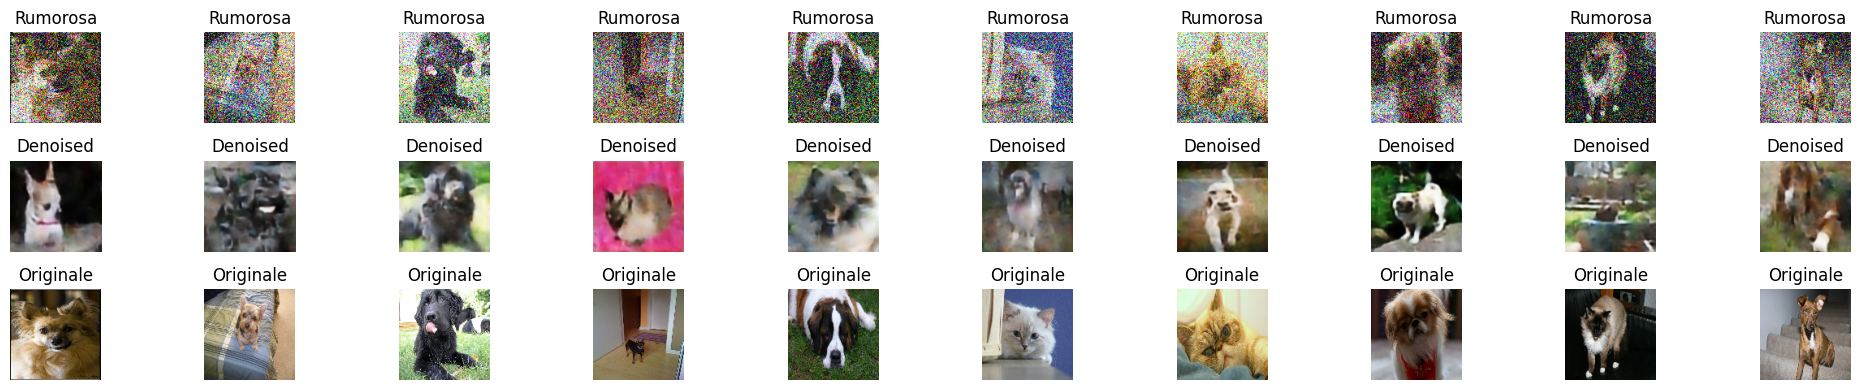

In [55]:
batch = next(iter(test_ds_noisy))

x_noisy_b, x_original_b = batch

x_noisy_np = x_noisy_b.numpy()
x_original_np = x_original_b.numpy()

plot_denoising_results(x_noisy_b, decoded_imgs, x_original_b, n=10)

In [56]:
print(history.history.keys())  # mostra le chiavi disponibili


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [57]:
print(history.history['accuracy'])

[0.7058534622192383, 0.7074577808380127, 0.7143767476081848, 0.7181606888771057, 0.7164356112480164, 0.7187892198562622, 0.7191624045372009, 0.7208561301231384, 0.7221394181251526, 0.7218352556228638, 0.7188733220100403, 0.7248015999794006, 0.724462628364563, 0.7264112234115601, 0.7257582545280457, 0.7273281216621399, 0.728568971157074, 0.7303167581558228, 0.7301786541938782, 0.7293915152549744, 0.729449987411499, 0.729357898235321, 0.7301449179649353, 0.7338282465934753, 0.7304257750511169, 0.7307682633399963, 0.7336953282356262, 0.732212245464325, 0.7332276105880737, 0.7331712245941162, 0.7330158948898315, 0.7325700521469116, 0.7346140146255493, 0.7352014183998108, 0.7330989241600037, 0.732568621635437, 0.7354523539543152, 0.7342902421951294, 0.7365707755088806, 0.7329748868942261, 0.7344491481781006, 0.7350212335586548, 0.7343189120292664, 0.7349691390991211, 0.7355772256851196, 0.734332799911499, 0.7358811497688293, 0.7378788590431213, 0.7372275590896606, 0.7362716197967529]


In [58]:
autoencoder.save('new_autoencoder.keras')

In [59]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epochs)

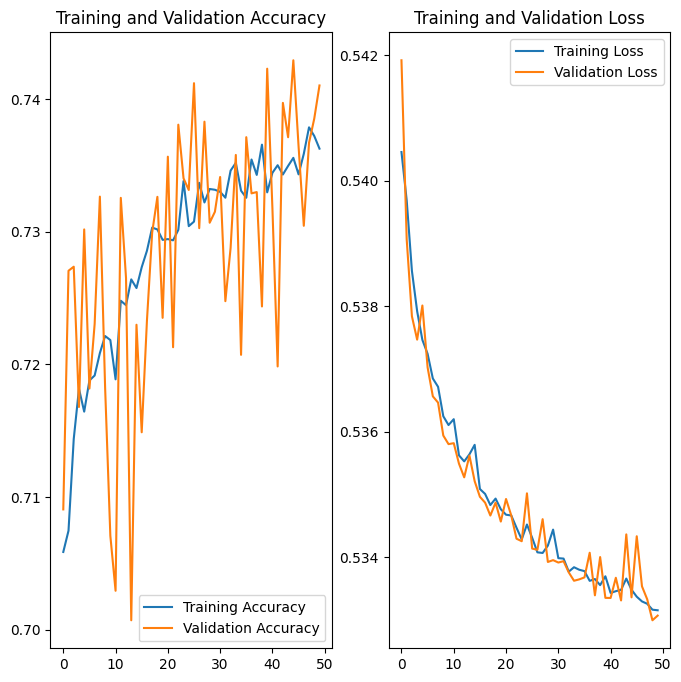

In [60]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [61]:
from skimage.metrics import peak_signal_noise_ratio as psnr

In [64]:
psnr_values = [psnr(x_noisy_np[i], decoded_imgs[i], data_range=1.0) for i in range(len(test_ds_noisy))]


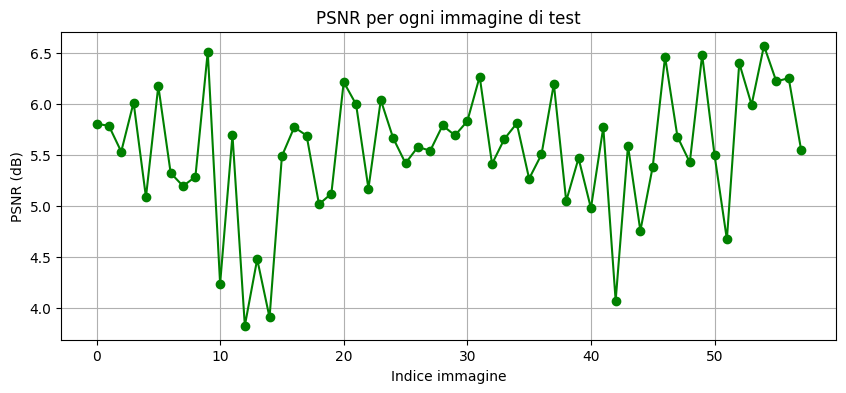

Media PSNR sul test set: 5.54 dB


In [65]:

# Plot dei PSNR per ogni immagine
plt.figure(figsize=(10, 4))
plt.plot(psnr_values, marker='o', linestyle='-', color='green')
plt.title('PSNR per ogni immagine di test')
plt.xlabel('Indice immagine')
plt.ylabel('PSNR (dB)')
plt.grid(True)
plt.show()

# (Facoltativo) Media PSNR
print(f"Media PSNR sul test set: {np.mean(psnr_values):.2f} dB")